## Initial models:

Training the NN model on the Fashion MNIST dataset.

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)


2.19.0


Loading the dateset

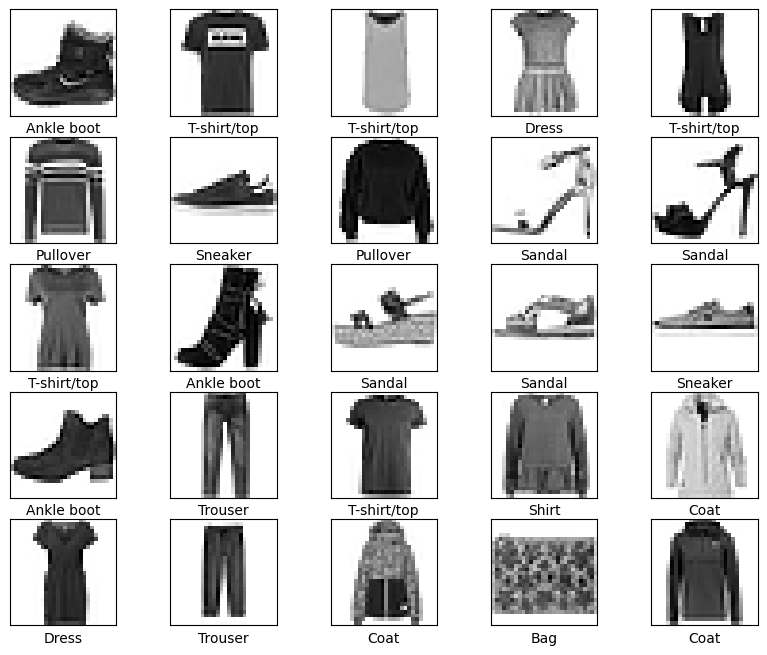

In [6]:
# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Vizualize the first 25 images from the training set   
plt.figure(figsize=(10, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()


In [7]:
# Train and test size for split
print("train_images shape:", train_images.shape)
print("test_images shape:", test_images.shape)

train_images shape: (60000, 28, 28)
test_images shape: (10000, 28, 28)


Before training the model, we perform feature scaling on the input images. Specifically, we normalize the pixel intensity values, which typically range from [0, 255], to the range [0, 1]. This is achieved by dividing every pixel value in the dataset by 255.0. Gradient-based optimization algorithms, which form the backbone of NN training, are sensitive to the scale of input features. Unscaled features can lead to disproportionately large gradients for some weights, potentially causing instability or requiring very small learning rates, thus slowing down training. Scaling to [0, 1] ensures all inputs contribute more equally to the optimization process.

In [ ]:
# Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

model_1 -- NN with 3 layers

model_2 -- NN with 6 layers

model_3 -- NN with 12 layers

Training the first NN model:

1. Building the architecture
2. Compiling the model
3. Training the model
4. Evaluate the model

In [23]:
# Build the 2 layer architecture, the first layer will not be couted as a computational layer.
model_1 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Flatten the 28x28 images into a 1D array of 784 elements
    keras.layers.Dense(128, activation='relu'), # First hidden layer with 128 neurons and ReLU activation
    keras.layers.Dense(10, activation='softmax') # Output layer with 10 neurons and softmax activation (for multi-class classification)
])

# Compile the model, using the Adam optimizer which implies momentum and decay.
model_1.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy', # Using cross-entropy loss for multi-class classification
                metrics=['accuracy']) 

model_1.summary()


d:\#Programare\Py VSC\NN\neural-networks\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# 80% of the data will be used for training and 20% for validation.
# The batch size is 16, which means that the model will process 16 images at a time.
# Because 80% is equivalent to 48000 images, the model will process 48000/16 = 3000 batches per epoch.
history_NN1_5 = model_1.fit(train_images, train_labels, epochs=5, batch_size=16, validation_split=0.2)

Epoch 1/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6656 - loss: 10.2877 - val_accuracy: 0.7428 - val_loss: 0.7464
Epoch 2/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7596 - loss: 0.6783 - val_accuracy: 0.7858 - val_loss: 0.6165
Epoch 3/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7735 - loss: 0.6478 - val_accuracy: 0.8119 - val_loss: 0.5927
Epoch 4/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8024 - loss: 0.5817 - val_accuracy: 0.8034 - val_loss: 0.6494
Epoch 5/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8092 - loss: 0.5697 - val_accuracy: 0.8041 - val_loss: 0.6245


In [ ]:
# Testing the models accuracy 
test_loss, test_acc = model_1.evaluate(test_images, test_labels)
print("Test loss. Model 1 - 2 layers: ", test_loss * 100)
print("Test accuracy. Model 1 - 2 layers: ", test_acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8020 - loss: 0.6467
Test loss. Model 1 - 2 layers:  66.48339629173279
Test accuracy. Model 1 - 2 layers:  79.65999841690063


Testing if deeper networks work better: NN-6, NN-12.

In [20]:
model_2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), 
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax') 
])

model_2.summary()

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy']) 

d:\#Programare\Py VSC\NN\neural-networks\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,306 (591.04 KB)

 Trainable params: 151,306 (591.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_NN2_5 = model_2.fit(train_images, train_labels, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6931 - loss: 2.8649 - val_accuracy: 0.8077 - val_loss: 0.5426
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8127 - loss: 0.5232 - val_accuracy: 0.8421 - val_loss: 0.4477
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8390 - loss: 0.4485 - val_accuracy: 0.8506 - val_loss: 0.4328
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8521 - loss: 0.4099 - val_accuracy: 0.8461 - val_loss: 0.4576
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8532 - loss: 0.3995 - val_accuracy: 0.8462 - val_loss: 0.4188


In [22]:
# Evaluating the 2nd model
test_loss, test_acc = model_2.evaluate(test_images, test_labels)
print("Test loss. Model 1 - 2 layers: ", test_loss * 100)
print("Test accuracy. Model 1 - 2 layers: ", test_acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8385 - loss: 0.4495
Test loss. Model 1 - 2 layers:  45.01692354679108
Test accuracy. Model 1 - 2 layers:  83.70000123977661


In [24]:
model_3 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), 
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax') 
])

model_3.summary()

model_3.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy']) 

d:\#Programare\Py VSC\NN\neural-networks\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_NN3_5 = model_3.fit(train_images, train_labels, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7194 - loss: 0.8262 - val_accuracy: 0.8290 - val_loss: 0.5037
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8306 - loss: 0.4854 - val_accuracy: 0.8425 - val_loss: 0.4591
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8459 - loss: 0.4391 - val_accuracy: 0.8547 - val_loss: 0.4280
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8561 - loss: 0.4125 - val_accuracy: 0.8569 - val_loss: 0.4127
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8654 - loss: 0.3883 - val_accuracy: 0.8609 - val_loss: 0.4121


In [26]:
test_loss, test_acc = model_3.evaluate(test_images, test_labels)
print("Test loss. Model 1 - 2 layers: ", test_loss * 100)
print("Test accuracy. Model 1 - 2 layers: ", test_acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8581 - loss: 0.4200
Test loss. Model 1 - 2 layers:  43.60884130001068
Test accuracy. Model 1 - 2 layers:  85.25000214576721


Testing the $1^{st}$ model for 50 epochs:

In [27]:
history_NN1_50 = model_1.fit(train_images, train_labels, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6816 - loss: 11.3099 - val_accuracy: 0.7064 - val_loss: 0.8368
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7231 - loss: 0.7353 - val_accuracy: 0.7232 - val_loss: 0.6938
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7592 - loss: 0.6255 - val_accuracy: 0.7058 - val_loss: 0.7372
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7651 - loss: 0.6204 - val_accuracy: 0.7537 - val_loss: 0.6900
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7770 - loss: 0.5812 - val_accuracy: 0.7333 - val_loss: 0.6911
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7827 - loss: 0.5575 - val_accuracy: 0.7801 - val_loss: 0.5794
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7941 - loss: 0.5340 - val_accuracy: 0.7938 - val_loss: 0.6453
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7992 - loss: 0.5278 -

In [61]:
test_loss, test_acc = model_1.evaluate(test_images, test_labels)
print("Test loss. Model 1 - 2 layers: ", test_loss * 100)
print("Test accuracy. Model 1 - 2 layers: ", test_acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8331 - loss: 0.5728  
Test loss. Model 1 - 2 layers:  60.75497269630432
Test accuracy. Model 1 - 2 layers:  82.77000188827515


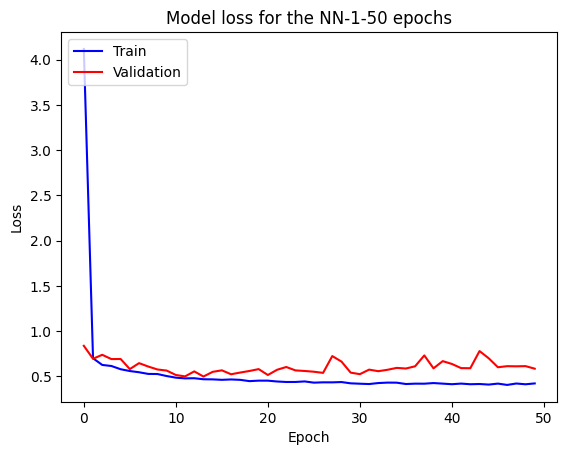

In [ ]:
# Plotting the loss  at each step: Model 1
plt.plot(history_NN1_50.history['loss'], 'blue')
plt.plot(history_NN1_50.history['val_loss'], 'red')
plt.title('Model loss for the NN-1-50 epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


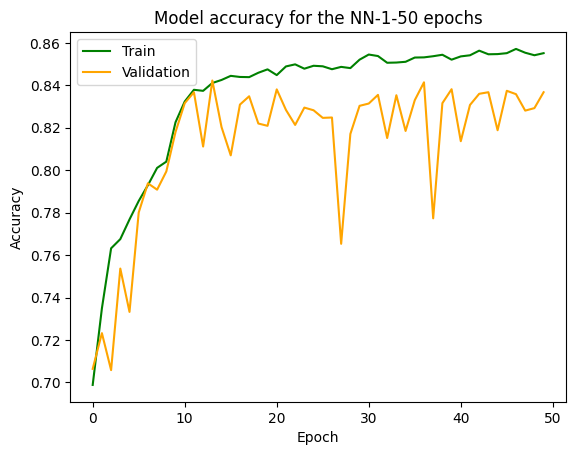

In [34]:
# Plotting the accuracy  at each step: Model 1
plt.plot(history_NN1_50.history['accuracy'], 'green')
plt.plot(history_NN1_50.history['val_accuracy'], 'orange')
plt.title('Model accuracy for the NN-1-50 epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [30]:
history_NN2_50 = model_2.fit(train_images, train_labels, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8654 - loss: 0.3722 - val_accuracy: 0.8547 - val_loss: 0.3981
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8684 - loss: 0.3601 - val_accuracy: 0.8397 - val_loss: 0.4776
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8736 - loss: 0.3475 - val_accuracy: 0.8601 - val_loss: 0.3997
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8776 - loss: 0.3393 - val_accuracy: 0.8597 - val_loss: 0.4091
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8818 - loss: 0.3298 - val_accuracy: 0.8344 - val_loss: 0.4815
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8808 - loss: 0.3323 - val_accuracy: 0.8612 - val_loss: 0.4032
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8836 - loss: 0.3132 - val_accuracy: 0.8662 - val_loss: 0.4087
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8868 - loss: 0.3114 - 

In [ ]:
test_loss, test_acc = model_2.evaluate(test_images, test_labels) # For 50 epochs
print("Test loss. Model 2 - 6 layers: ", test_loss * 100)
print("Test accuracy. Model 2 - 6 layers: ", test_acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8771 - loss: 0.5433
Test loss. Model 2 - 2 layers:  48.05324077606201
Test accuracy. Model 2 - 2 layers:  87.81999945640564


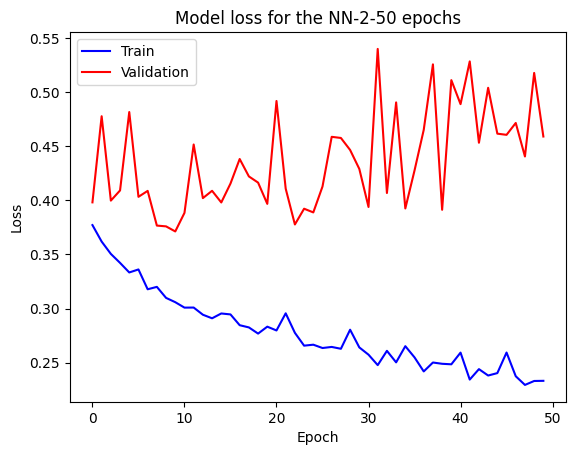

In [31]:
# Plotting the loss and accuracy at each step: Model 2
plt.plot(history_NN2_50.history['loss'], 'blue')
plt.plot(history_NN2_50.history['val_loss'], 'red')
plt.title('Model loss for the NN-2-50 epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

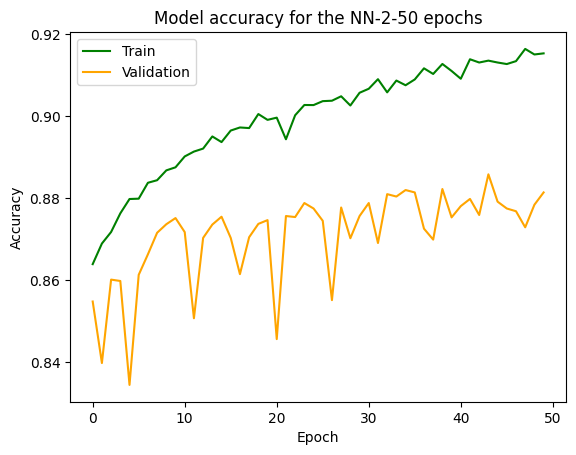

In [35]:
# Plotting the accuracy  at each step: Model 2
plt.plot(history_NN2_50.history['accuracy'], 'green')
plt.plot(history_NN2_50.history['val_accuracy'], 'orange')
plt.title('Model accuracy for the NN-2-50 epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [32]:
history_NN3_50 = model_3.fit(train_images, train_labels, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8691 - loss: 0.3674 - val_accuracy: 0.8573 - val_loss: 0.4096
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8716 - loss: 0.3659 - val_accuracy: 0.8747 - val_loss: 0.3603
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8772 - loss: 0.3462 - val_accuracy: 0.8541 - val_loss: 0.4298
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8778 - loss: 0.3455 - val_accuracy: 0.8742 - val_loss: 0.3985
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8808 - loss: 0.3343 - val_accuracy: 0.8561 - val_loss: 0.4201
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8878 - loss: 0.3167 - val_accuracy: 0.8684 - val_loss: 0.4220
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8892 - loss: 0.3147 - val_accuracy: 0.8763 - val_loss: 0.4007
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8912 - loss: 0.3187 - 

In [64]:
test_loss, test_acc = model_3.evaluate(test_images, test_labels) # For 50 epochs
print("Test loss. Model 3 - 12 layers: ", test_loss * 100)
print("Test accuracy. Model 3 - 12 layers: ", test_acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8692 - loss: 0.4312
Test loss. Model 3 - 12 layers:  44.04842257499695
Test accuracy. Model 3 - 12 layers:  87.08999752998352


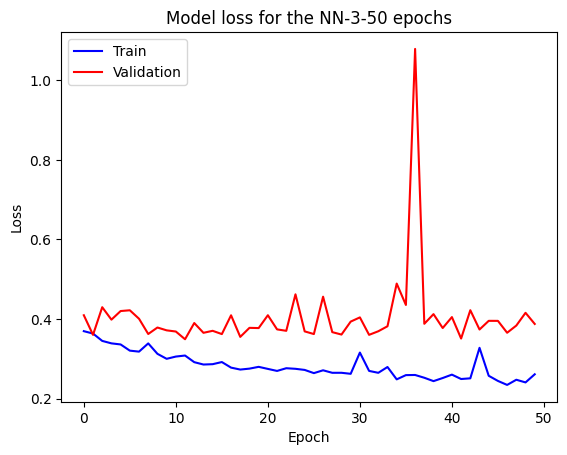

In [33]:
# Plotting the loss and accuracy at each step: Model 3
plt.plot(history_NN3_50.history['loss'], 'blue')
plt.plot(history_NN3_50.history['val_loss'], 'red')
plt.title('Model loss for the NN-3-50 epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

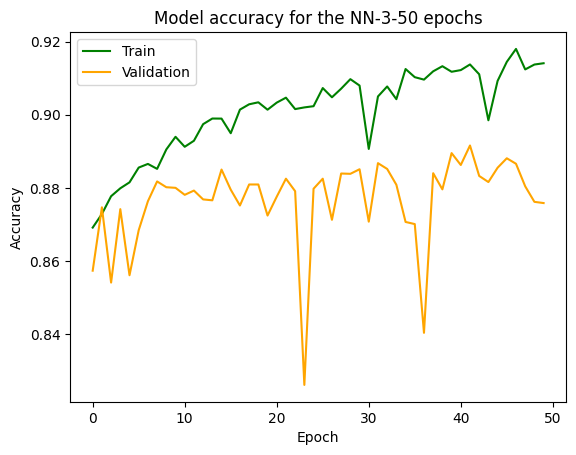

In [36]:
# Plotting the accuracy  at each step: Model 3
plt.plot(history_NN3_50.history['accuracy'], 'green')
plt.plot(history_NN3_50.history['val_accuracy'], 'orange')
plt.title('Model accuracy for the NN-3-50 epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Making predictions for the NN with 3 layers

In [37]:
predictions1 = model_1.predict(test_images)
predictions1.shape
predictions1[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 2.3213204e-37,
       0.0000000e+00, 1.8394319e-03, 0.0000000e+00, 4.6820194e-03,
       8.9766121e-28, 9.9347854e-01], dtype=float32)

In [38]:
np.argmax(predictions1[0])


np.int64(9)

In [39]:
class_names[9]

'Ankle boot'

In [41]:
# Plotting a grid for the predictions

def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    
    plt.xlabel("{} {:2.0f}% ({})". format(class_names[predicted_label],
                                   100*np.max(predictions_array),
                                   class_names[true_label]),
                                   color=color)
    
# Plotting the value array
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')
    

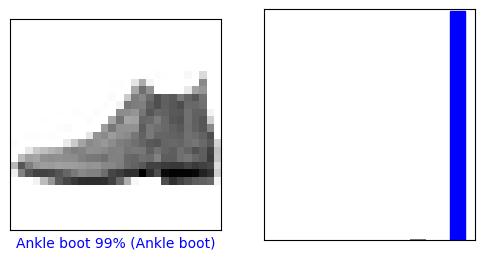

In [44]:
# Looking at the first image, predictions, and prediction array
i = 0
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plot_image(i, predictions1, test_labels, test_images)
plt.subplot(1, 2, 2)
plot_value_array(i, predictions1, test_labels)


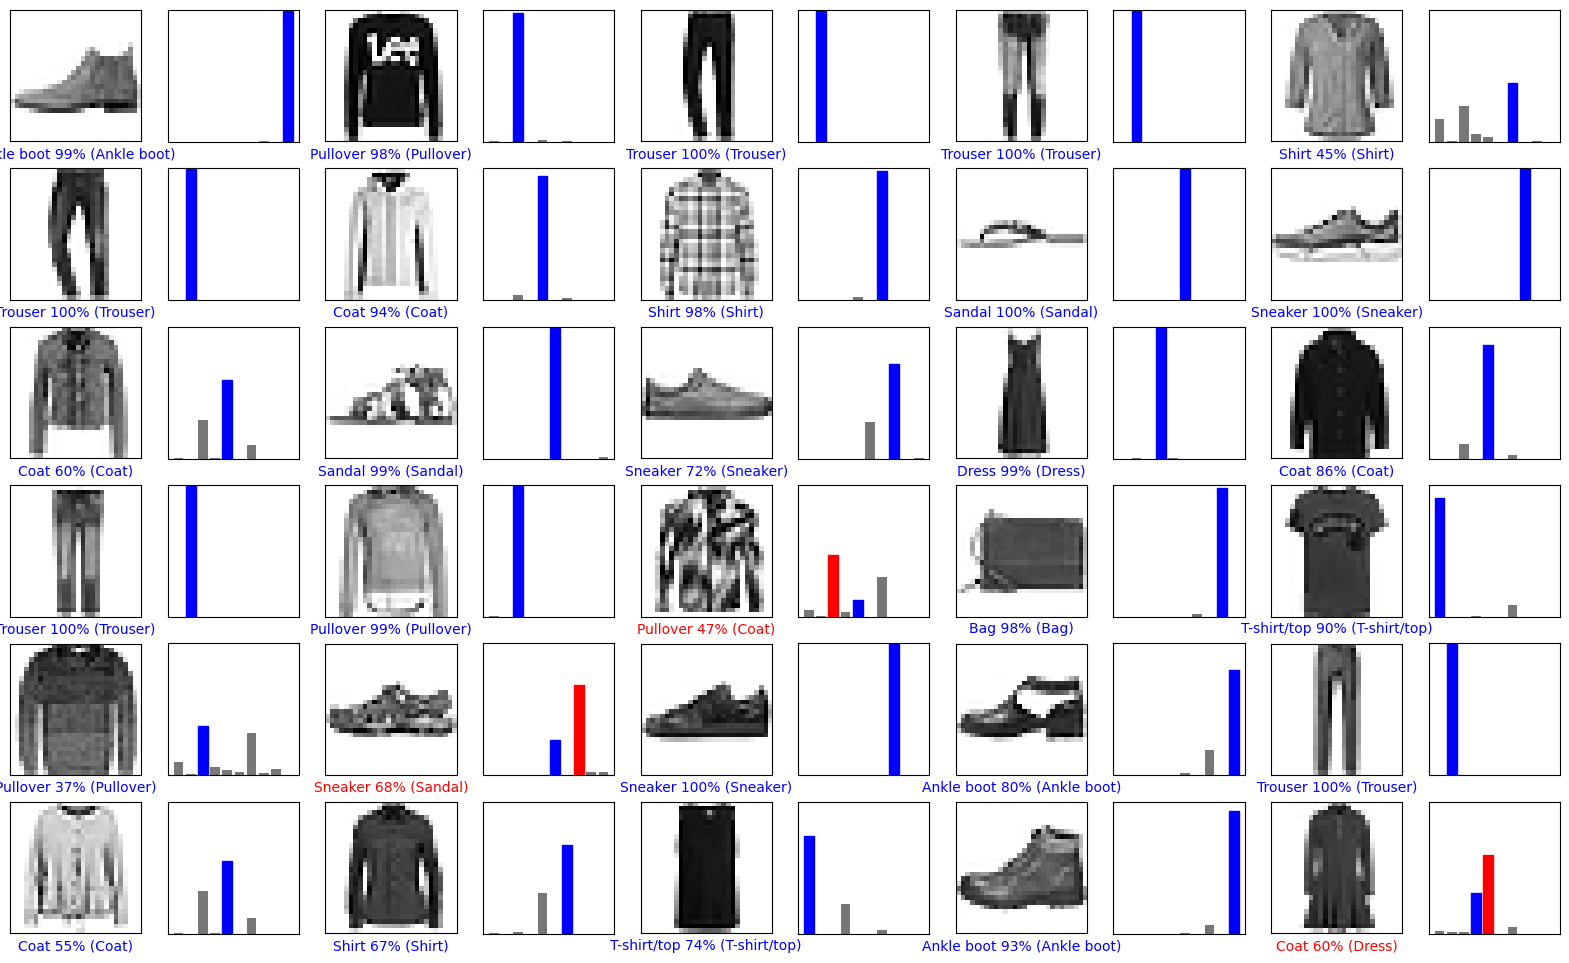

In [46]:
# Plot the first 30 images, their predicted label and their true label
num_rows = 6
num_cols = 5 
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions1, test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions1, test_labels)


In [47]:
predictions2 = model_2.predict(test_images)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


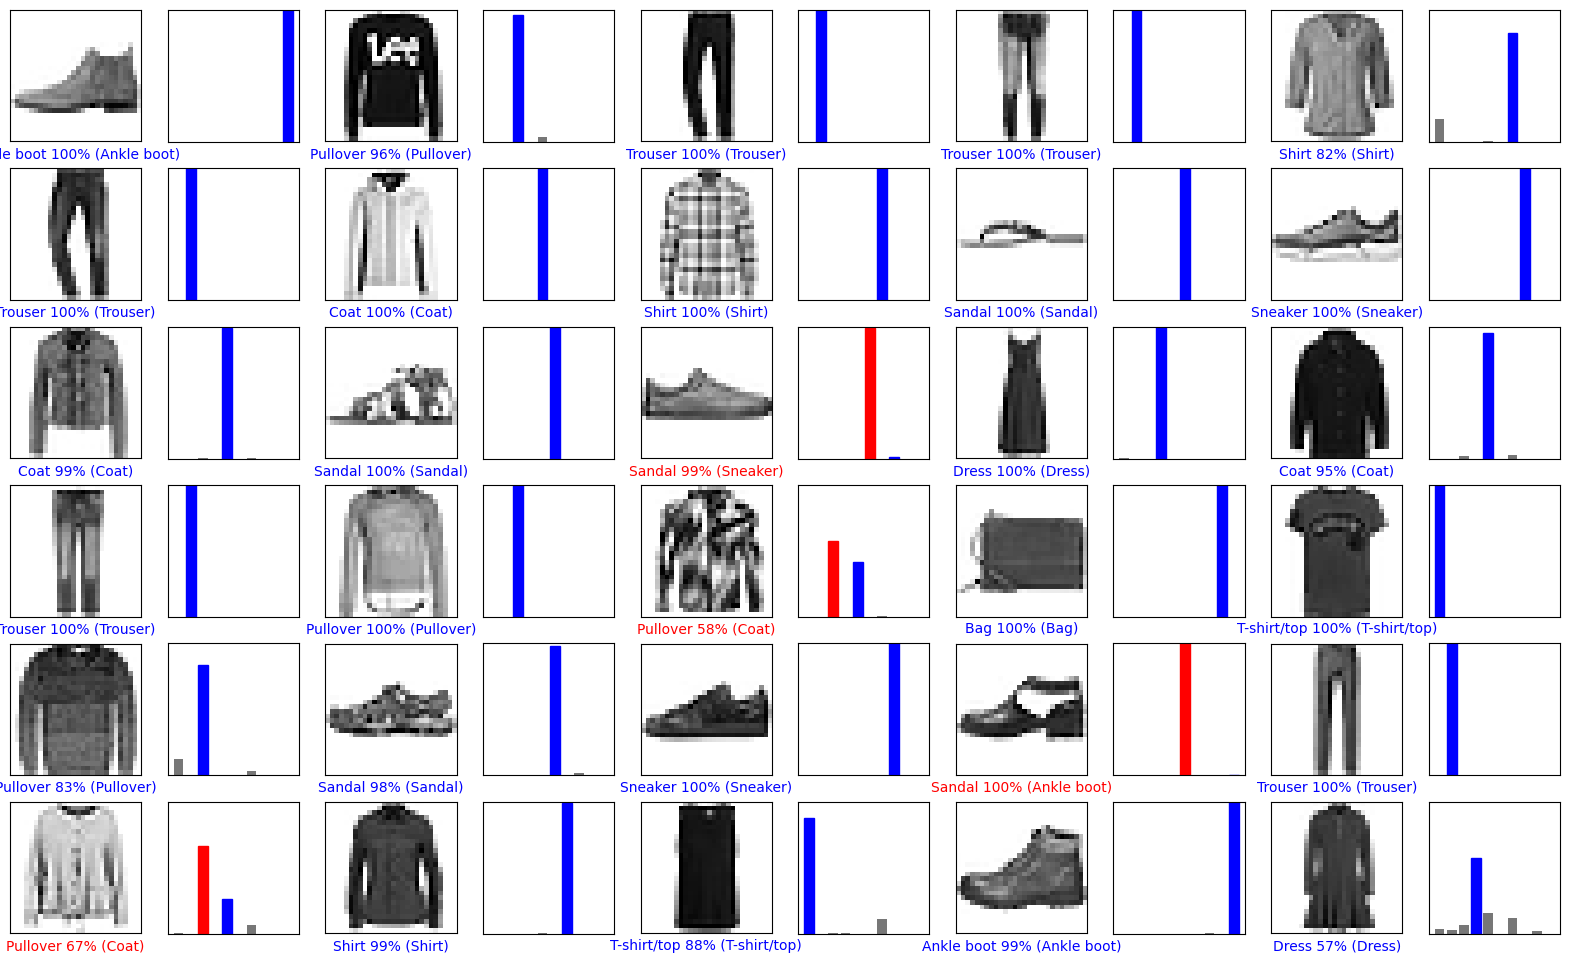

In [48]:
# Plot the first 30 images, their predicted label and their true label for the 2nd model
num_rows = 6
num_cols = 5 
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions2, test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions2, test_labels)

In [49]:
predictions3 = model_3.predict(test_images)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


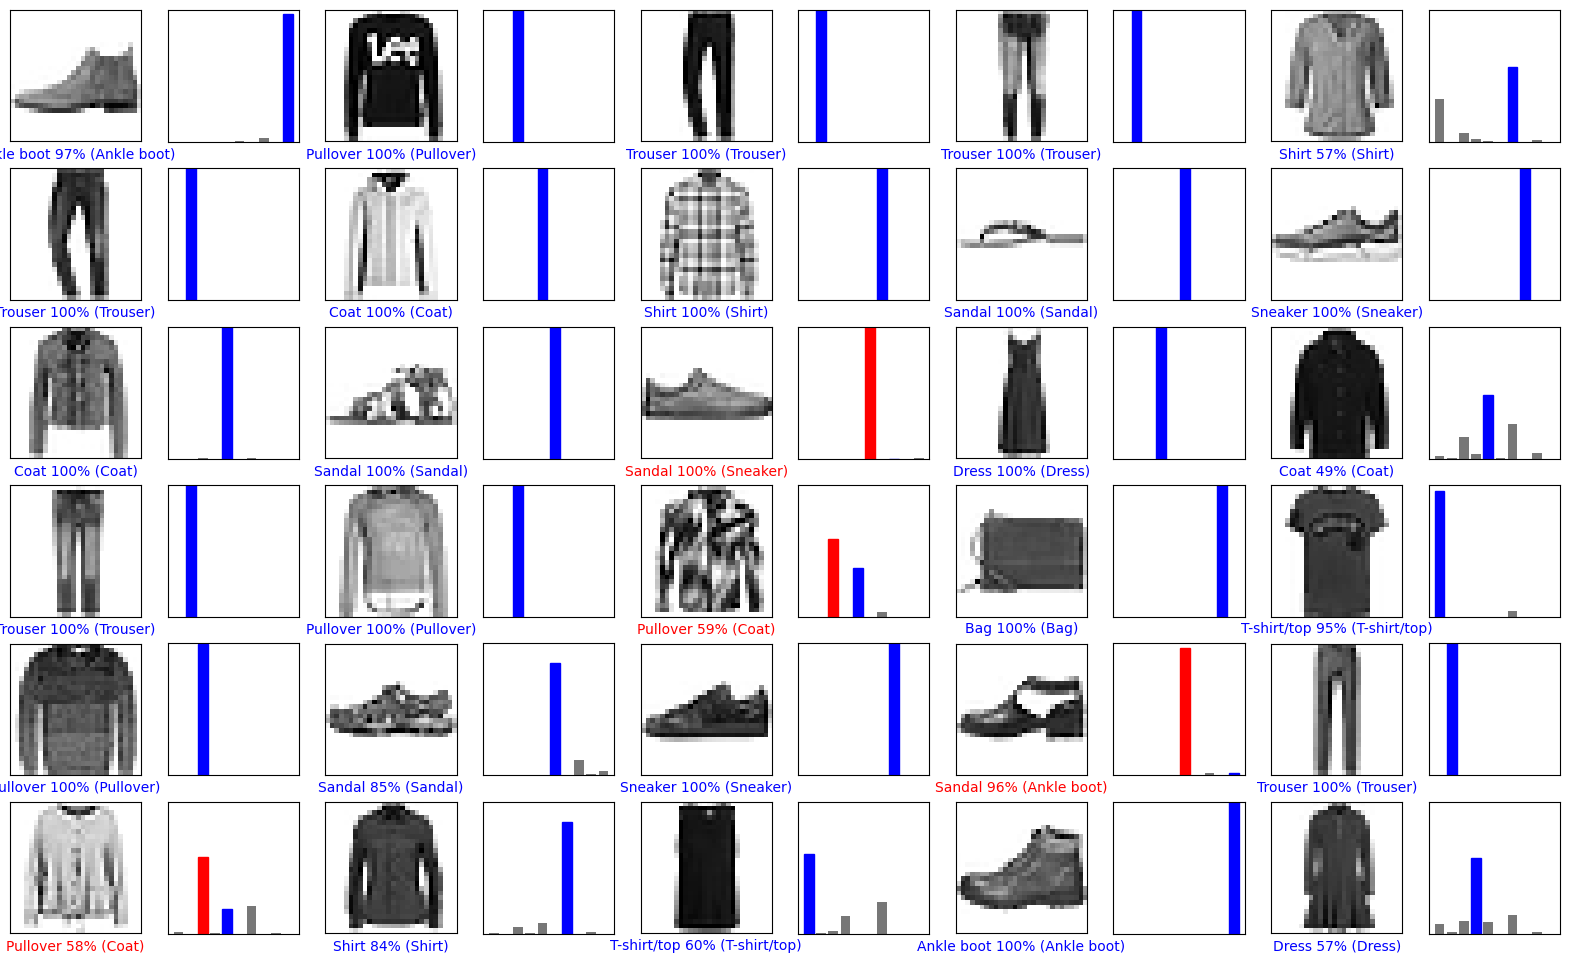

In [50]:
# Plot the first 30 images, their predicted label and their true label for the 2nd model
num_rows = 6
num_cols = 5 
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions3, test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions3, test_labels)

## ASSIGNMENT:

Modify the notebook to train the network with 9 layers (in addition to 3,6 and 12) for both 5 and 50 epochs. Save the file as NN_MNIST_depth_9.ipynb 

In [51]:
model_NN_9 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), 
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model_NN_9.summary()

model_NN_9.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy']) 


d:\#Programare\Py VSC\NN\neural-networks\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,842 (784.54 KB)

 Trainable params: 200,842 (784.54 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history_NN9_5 = model_NN_9.fit(train_images, train_labels, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7080 - loss: 1.0507 - val_accuracy: 0.8419 - val_loss: 0.4529
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8351 - loss: 0.4671 - val_accuracy: 0.8388 - val_loss: 0.4569
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8485 - loss: 0.4199 - val_accuracy: 0.8537 - val_loss: 0.4199
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8632 - loss: 0.3868 - val_accuracy: 0.8573 - val_loss: 0.3986
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8660 - loss: 0.3791 - val_accuracy: 0.8490 - val_loss: 0.4250


In [53]:
test_loss, test_acc = model_NN_9.evaluate(test_images, test_labels)
print("Test loss. Model 9 - 9 layers: ", test_loss * 100)
print("Test accuracy. Model 9 - 9 layers: ", test_acc * 100)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8422 - loss: 0.4352
Test loss. Model 9 - 9 layers:  44.338104128837585
Test accuracy. Model 9 - 9 layers:  84.0399980545044


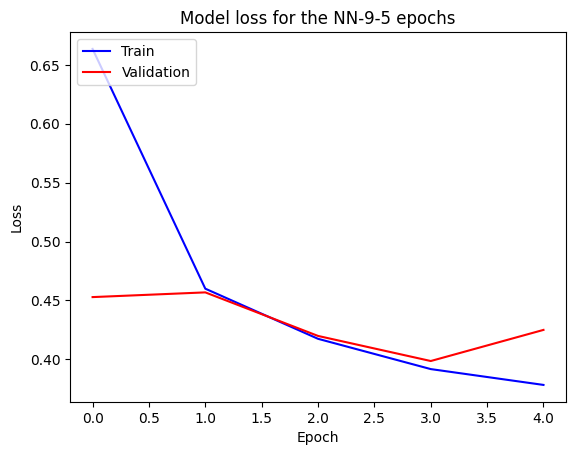

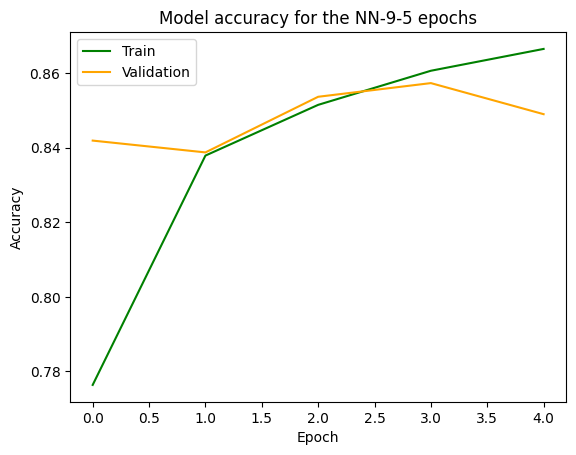

In [54]:
# Plotting the loss  at each step: Model 9
plt.plot(history_NN9_5.history['loss'], 'blue')
plt.plot(history_NN9_5.history['val_loss'], 'red')
plt.title('Model loss for the NN-9-5 epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting the accuracy  at each step: Model 9
plt.plot(history_NN9_5.history['accuracy'], 'green')
plt.plot(history_NN9_5.history['val_accuracy'], 'orange')
plt.title('Model accuracy for the NN-9-5 epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [55]:
history_NN9_50 = model_NN_9.fit(train_images, train_labels, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8733 - loss: 0.3543 - val_accuracy: 0.8562 - val_loss: 0.4152
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8746 - loss: 0.3519 - val_accuracy: 0.8688 - val_loss: 0.3822
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8836 - loss: 0.3293 - val_accuracy: 0.8427 - val_loss: 0.4223
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8787 - loss: 0.3306 - val_accuracy: 0.8738 - val_loss: 0.3653
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8857 - loss: 0.3155 - val_accuracy: 0.8667 - val_loss: 0.3843
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8845 - loss: 0.3159 - val_accuracy: 0.8718 - val_loss: 0.3830
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8871 - loss: 0.3076 - val_accuracy: 0.8766 - val_loss: 0.3706
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8926 - loss: 0.2961 - 

In [56]:
test_loss, test_acc = model_NN_9.evaluate(test_images, test_labels)
print("Test loss. Model 9 - 9 layers: ", test_loss * 100)
print("Test accuracy. Model 9 - 9 layers: ", test_acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8702 - loss: 1.1383
Test loss. Model 9 - 9 layers:  81.93650245666504
Test accuracy. Model 9 - 9 layers:  87.26000189781189


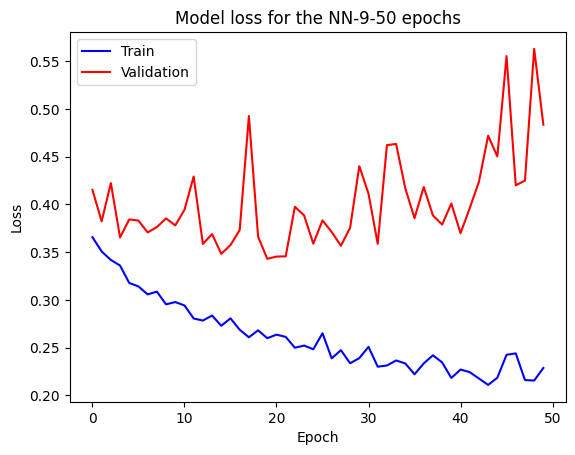

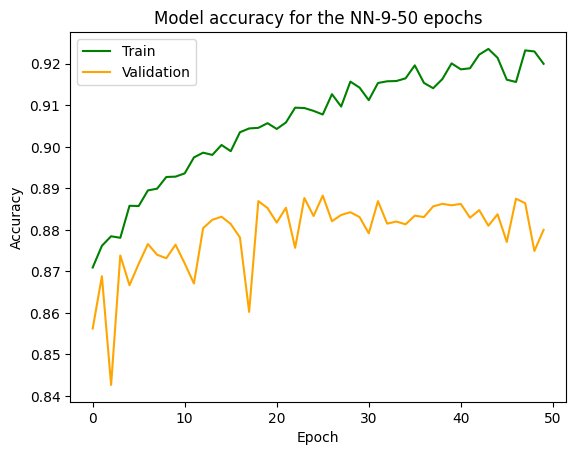

In [58]:
# Plotting the loss  at each step: Model 9
plt.plot(history_NN9_50.history['loss'], 'blue')
plt.plot(history_NN9_50.history['val_loss'], 'red')
plt.title('Model loss for the NN-9-50 epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history_NN9_50.history['accuracy'], 'green')
plt.plot(history_NN9_50.history['val_accuracy'], 'orange')
plt.title('Model accuracy for the NN-9-50 epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [59]:
predictions4 = model_NN_9.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


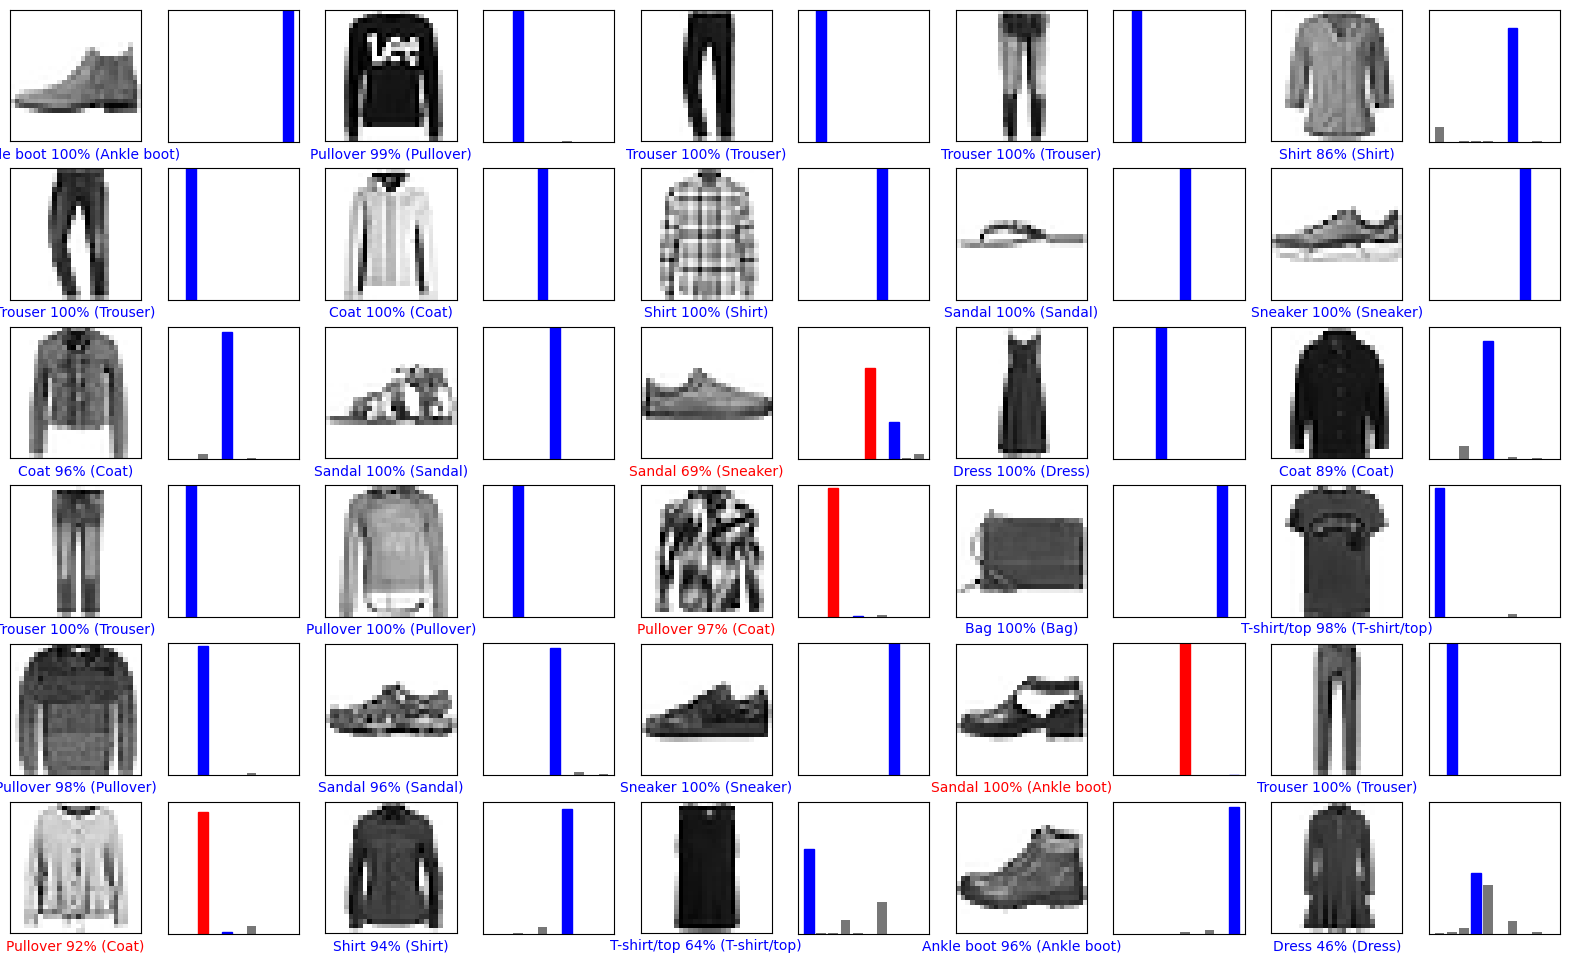

In [60]:
# Plot the first 30 images, their predicted label and their true label for the 4nd model (NN with 9 layers)
num_rows = 6
num_cols = 5 
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions4, test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions4, test_labels)

Observations:

Consistent with previous model iterations, this model struggles to differentiate between certain categories. Specifically, it has difficulty distinguishing sandals from sneakers/ankle boots, and pullovers from coats (those error are caused by simililarities in these low level resolution photos but also the representation in only greyscale).

General model performances soo far:
1. 3 Layers: 79.65999841690063 - 5 epochs, 82.77000188827515 - 50 epochs

2. 6 Layers: 83.70000123977661 - 5 epochs, 87.81999945640564 - 50 epochs

3. 9 Layers: 84.0399980545044 - 5 epochs, 87.26000189781189 - 50 epochs

4. 12 Layers: 85.25000214576721 - 5 epochs, 87.08999752998352 - 50 epochs

After 5 training epochs, the 12-layer Neural Network (NN) performed slightly better than the 6- and 9-layer networks, suggesting a marginal initial benefit from increased depth. However, when training was extended to 50 epochs, the performance differences between these 6-, 9-, and 12-layer networks became negligible. Despite this convergence among the deeper models, it is noteworthy that they generally still achieve better performance than a simpler 3-layer NN baseline.

A common challenge observed across all models during longer training periods was a tendency towards overfitting. This manifested as a steady improvement in accuracy and loss on the training dataset, while the corresponding metrics on the validation set became noisy or plateaued, failing to mirror the training trends and indicating poor generalization.